In [ ]:
!pip install --upgrade pip

In [ ]:
!pip install --upgrade ipykernel ipywidgets jupyter

In [ ]:
!pip install faiss-cpu sentence_transformers numpy pandas openpyxl einops matplotlib plotly scikit-learn

In [ ]:
import os

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

from sentence_transformers import SentenceTransformer
import faiss




os.environ["HF_TOKEN"] = "123"  # Hugging face token

In [11]:
# 1. Загружаем модель-энкодер (она УЖЕ без последних слоев для генерации текста)
# Специализированные модели для векторных представлений предложений

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"  # 700 Mb
# model_name = "ai-sage/Giga-Embeddings-instruct"  # 15 Gb


model = SentenceTransformer(model_name, trust_remote_code=True)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [12]:
# 2. Твой список предложений (твоя "база знаний")
# sentences = [
#     "Как испечь пирог с яблоками?",
#     "Как приготовить яблочный пирог?",
#     "Рецепт шарлотки с яблоками",
#     "Какая погода в Москве сегодня?",
#     "Прогноз погоды на завтра",
#     "Сильный дождь и ветер в столице",
#     "Лучшие фильмы 2023 года",
#     "Список кинопремьер прошлого года",
#     "Как сварить кофе в турке",
#     "Рецепт приготовления эспрессо",
#     "Температура воздуха в Лондоне",
# ]


sentences_file = pd.read_excel("/Users/phil/GitHub/masters_degree_Roshchin_M25-555/rag/mkb10.xlsx", dtype=str)

In [ ]:
sentences_file

In [13]:
sentences = sentences_file["Название диагноза"].tolist()
mkb_codes = sentences_file["Код диагноза"].tolist()

In [14]:
# 3. Конвертируем все предложения в векторы одинаковой длины
embeddings = model.encode(sentences, show_progress_bar=True)

Batches:   0%|          | 0/383 [00:00<?, ?it/s]

## PCA

In [15]:
# 3. PCA анализ
print("Выполняем PCA...")
# Нормализуем данные перед PCA
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

# Применяем PCA
n_components = 50  # Сначала возьмем 50 компонент для анализа
pca = PCA(n_components=n_components)
embeddings_pca = pca.fit_transform(embeddings_scaled)

# 4. Анализ объясненной дисперсии
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("\n=== АНАЛИЗ ГЛАВНЫХ КОМПОНЕНТ ===")
print(f"Общее количество компонент: {n_components}")
print(f"Первая компонента объясняет: {explained_variance_ratio[0]:.2%} дисперсии")
print(f"Первые 2 компоненты объясняют: {cumulative_variance[1]:.2%} дисперсии")
print(f"Первые 5 компонент объясняют: {cumulative_variance[4]:.2%} дисперсии")
print(f"Первые 10 компонент объясняют: {cumulative_variance[9]:.2%} дисперсии")
print(f"Первые 50 компонент объясняют: {cumulative_variance[49]:.2%} дисперсии")

Выполняем PCA...

=== АНАЛИЗ ГЛАВНЫХ КОМПОНЕНТ ===
Общее количество компонент: 50
Первая компонента объясняет: 7.76% дисперсии
Первые 2 компоненты объясняют: 13.97% дисперсии
Первые 5 компонент объясняют: 28.95% дисперсии
Первые 10 компонент объясняют: 42.54% дисперсии
Первые 50 компонент объясняют: 79.73% дисперсии


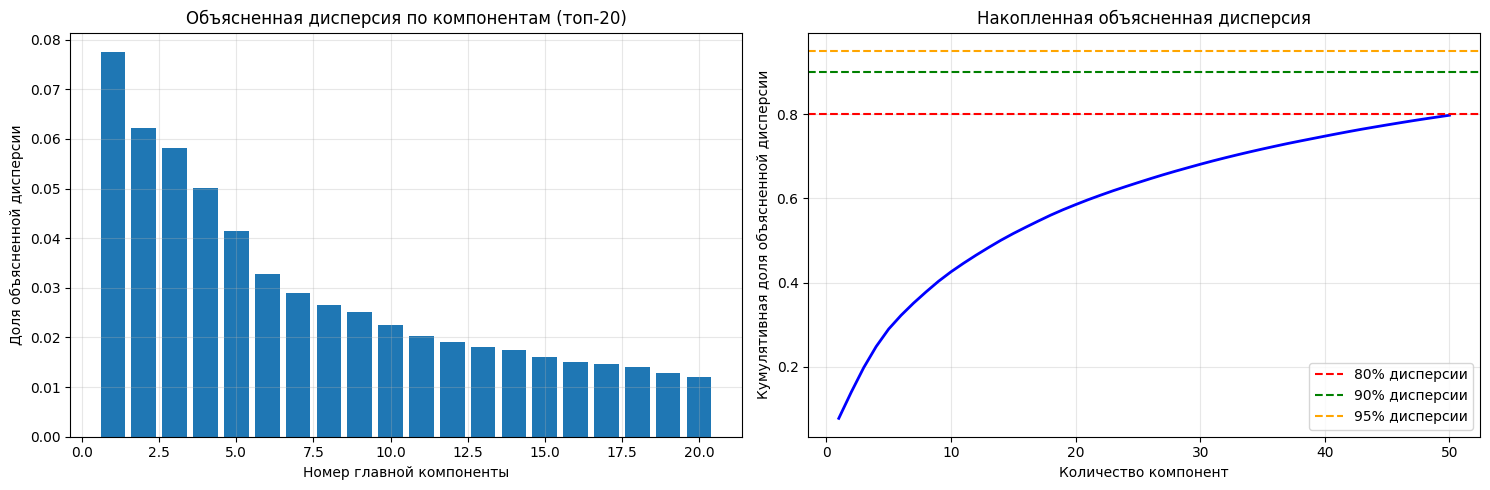

In [16]:
# 5. Визуализация explained variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Индивидуальная объясненная дисперсия
axes[0].bar(range(1, 21), explained_variance_ratio[:20])
axes[0].set_xlabel('Номер главной компоненты')
axes[0].set_ylabel('Доля объясненной дисперсии')
axes[0].set_title('Объясненная дисперсия по компонентам (топ-20)')
axes[0].grid(True, alpha=0.3)

# График 2: Кумулятивная дисперсия
axes[1].plot(range(1, n_components + 1), cumulative_variance, 'b-', linewidth=2)
axes[1].axhline(y=0.8, color='r', linestyle='--', label='80% дисперсии')
axes[1].axhline(y=0.9, color='g', linestyle='--', label='90% дисперсии')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% дисперсии')
axes[1].set_xlabel('Количество компонент')
axes[1].set_ylabel('Кумулятивная доля объясненной дисперсии')
axes[1].set_title('Накопленная объясненная дисперсия')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# 6. Визуализация в 2D пространстве (первые 2 компоненты)
pca_2d = PCA(n_components=2)
embeddings_2d = pca_2d.fit_transform(embeddings_scaled)

In [ ]:
import plotly.graph_objects as go
from ipywidgets import interact, Dropdown
import numpy as np

# Создаем все проекции заранее (берем, например, первые 10 компонент)
n_components_to_show = 10
pca_all = PCA(n_components=n_components_to_show)
embeddings_all = pca_all.fit_transform(embeddings_scaled)

# Группируем по категориям МКБ
categories = {}
for i, code in enumerate(mkb_codes):
    cat = code[0] if code else '?'
    if cat not in categories:
        categories[cat] = {
            'indices': [],
            'text': [],
            'codes': []
        }
    categories[cat]['indices'].append(i)
    categories[cat]['text'].append(sentences[i])
    categories[cat]['codes'].append(code)

# Функция для отрисовки графика с выбранными компонентами
def plot_pca_components(pc_x=0, pc_y=1):
    fig = go.Figure()
    
    for cat, data in categories.items():
        indices = data['indices']
        fig.add_trace(go.Scatter(
            x=embeddings_all[indices, pc_x],
            y=embeddings_all[indices, pc_y],
            mode='markers',
            name=f'Категория {cat}',
            text=[f"{t[:40]}..." if len(t) > 40 else t for t in data['text']],
            marker=dict(size=8),
            hovertemplate='%{text}<br>Код: %{customdata}<extra></extra>',
            customdata=data['codes']
        ))
    
    explained_x = pca_all.explained_variance_ratio_[pc_x]
    explained_y = pca_all.explained_variance_ratio_[pc_y]
    
    fig.update_layout(
        title=f'PCA: PC{pc_x+1} vs PC{pc_y+1}<br>Объяснено: {explained_x+explained_y:.2%} дисперсии',
        xaxis_title=f'PC{pc_x+1} ({explained_x:.2%} дисперсии)',
        yaxis_title=f'PC{pc_y+1} ({explained_y:.2%} дисперсии)',
        hovermode='closest',
        width=1000,
        height=700
    )
    
    fig.show()

# Создаем интерактивные слайдеры
component_options = [(f'PC{i+1} ({pca_all.explained_variance_ratio_[i]:.2%})', i) for i in range(n_components_to_show)]

interact(
    plot_pca_components,
    pc_x=Dropdown(options=component_options, value=0, description='Ось X:'),
    pc_y=Dropdown(options=component_options, value=1, description='Ось Y:')
)

interactive(children=(Dropdown(description='Ось X:', options=(('PC1 (7.76%)', 0), ('PC2 (6.22%)', 1), ('PC3 (5…

<function __main__.plot_pca_components(pc_x=0, pc_y=1)>

## Поиск похожих предложений

In [25]:
embeddings = np.array(embeddings).astype("float64")

print(f"Размерность одного вектора: {embeddings.shape[1]}")  # Например, 384

# 4. Строим векторную базу данных с помощью FAISS
dimension = embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)  # L2 distance (евклидово расстояние)
index.add(embeddings)

print(f"Количество векторов в базе: {index.ntotal}")

Размерность одного вектора: 384
Количество векторов в базе: 12256


In [26]:
# 5. Функция поиска похожих предложений
def search_similar(query, top_k=3):
    # Конвертируем запрос в вектор
    query_vector = model.encode([query]).astype("float64")

    # Ищем top_k ближайших соседей
    distances, indices = index.search(query_vector, top_k)

    results = []
    for idx, distance in zip(indices[0], distances[0]):
        results.append(
            {
                "mkb_code": mkb_codes[idx],
                "sentence": sentences[idx],
                "distance": float(distance),
                "similarity": 1 / (1 + distance),  # Простая конвертация расстояния в "похожесть"
            }
        )

    return results

In [27]:
# 6. Тестируем
user_query = "Вирусные лихорадки, передаваемые членистоногими, и вирусные геморрагические лихорадки"
# user_query = "Найди похожие предложения: членистоногими"
user_query = "сахарный диабет второго типа"
results = search_similar(user_query, top_k=10)

print(f"\nЗапрос: '{user_query}'")
print("Результаты:")
for res in results:
    print(f"- [{res['mkb_code']}] {res['sentence']} (score: {res['similarity']:.6f})")


Запрос: 'сахарный диабет второго типа'
Результаты:
- [E13] Другие уточненные формы сахарного диабета (score: 0.212894)
- [E14] Сахарный диабет неуточненный (score: 0.180244)
- [E10-E14] Сахарный диабет (score: 0.178207)
- [E10] Инсулинзависимый сахарный диабет (score: 0.165387)
- [E11] Инсулиннезависимый сахарный диабет (score: 0.163967)
- [E23.2] Несахарный диабет (score: 0.154266)
- [O24.3] Существовавший ранее сахарный диабет неуточненный (score: 0.144669)
- [O24.1] Существовавший ранее сахарный диабет инсулиннезависимый (score: 0.142336)
- [O24.0] Существовавший ранее сахарный диабет инсулинзависимый (score: 0.135550)
- [N25.1] Нефрогенный несахарный диабет (score: 0.130174)
